# 0601 — NLP Transformer: miniBabel Address-to-Zone Classifier

Trains a custom Transformer classifier that reads a raw dropoff address string and predicts which of Mexico City's ~40 zones it belongs to — a text-to-zone translator standing in for structured geocoding. Builds up through classical NLP (TF-IDF signal extraction, Word2Vec semantic proximity) before the neural stage, and separately explores fine-tuning BETO (Spanish BERT) as an alternative architecture.

```mermaid
flowchart TD
    A["pienza.db: raw_offers_ocr + silver_palette"] --> B["Phase 2\nZone labeling: strategic grouping,\nmaster coalesce, airport fusion"]
    B --> C["Phase 3\nAddress standardization\n(Hard-Cut) + TF-IDF signals"]
    C --> D["Phase 4\nWord2Vec semantic\nproximity"]
    C --> E["Phase 5\nNeural preprocessing,\nTransformer architecture + training"]
    E --> F["Phase 6\nRandomized hit/miss audit"]
    C --> G["Phase 7\nAlternate architecture:\nBETO (Spanish BERT) fine-tune"]
    E --> H["Phase 8\nExport artifacts:\nvocab + semantic map for production"]

    classDef default stroke:#21918c,stroke-width:2px;
    linkStyle default stroke:#21918c,stroke-width:2px;
```


## Phase 1 — Setup

Unifies imports, connects to `pienza.db`, sets the Pienza visual canon, and authenticates against Hugging Face (needed for the BETO experiment in Phase 7).

#### 1.1 — Bootstrap: imports, database, visual canon

In [18]:
import copy
import json
import logging
import math
import multiprocessing
import os
import random
import string
import unicodedata
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import regex as re
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from gensim.models import Word2Vec
from huggingface_hub import login
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset, TensorDataset
from transformers import AutoModel, AutoTokenizer
from transformers import logging as hf_logging

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Silence TensorFlow warnings
os.environ['CUDA_VISIBLE_DEVICES'] = ''   # Force CPU: no GPU lookup in this environment

pd.options.mode.chained_assignment = None

# --- Persistence config (avoid re-training on every run) ---
DATE_PREFIX = "260422"  # Date of the pre-trained models
NOTEBOOK_ID = "0601"
FORCE_UPDATE = False

BASE_DIR = "/workspaces/pienza"
DUMP_DIR = os.path.join(BASE_DIR, "data/dumped_files")
os.makedirs(DUMP_DIR, exist_ok=True)

print(f"Cache directory ready: {DUMP_DIR}")

# --- Database connection ---
print("Connecting to the database...")
DB_PATH = '/workspaces/pienza/data/pienza.db'

if not os.path.exists(DB_PATH):
    print(f"CRITICAL: database not found at {DB_PATH}")
else:
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print(f"SQL engine active: {DB_PATH}")

# --- Pienza visual canon ---
PIENZA_PURPLE = '#440154'
PIENZA_TEAL = '#21918c'
PIENZA_GREY = '#FAFAFA'
PIENZA_TEXT = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': PIENZA_GREY,
    'axes.facecolor': PIENZA_GREY,
    'text.color': PIENZA_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': PIENZA_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 22,
    'figure.titleweight': 'bold'
})

print("Visual identity loaded.")

# --- Anonymization helper (per assets_ignored/CLAUDE.md canon) ---
# Masks a street number digit-by-digit with '#', preserving 5-digit postal codes.
# Applies to anything DISPLAYED/PRINTED, never to data written to disk for downstream use.
def _obf_address(v):
    if v is None or str(v) in ("None", "nan", ""):
        return "\u2014"
    _mask_digits = lambda m: re.sub(r'\d', '#', m.group(0))
    return re.sub(r'\b(?!\d{5}\b)\d+[\w-]*\b', _mask_digits, str(v), count=1)

print(f"Device detected: {'GPU (CUDA)' if torch.cuda.is_available() else 'CPU'}")


Cache directory ready: /workspaces/pienza/data/dumped_files
Connecting to the database...
SQL engine active: /workspaces/pienza/data/pienza.db
Visual identity loaded.
Device detected: CPU


#### 1.2 — Hugging Face authentication

Logs in via `HF_TOKEN` (needed for the BETO experiment in Phase 7).

In [19]:
token = os.getenv('HF_TOKEN')
if token:
    login(token=token)
    print("Authenticated with Hugging Face.")
else:
    print("HF_TOKEN not found in environment variables.")


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Authenticated with Hugging Face.


## Phase 2 — Zone labeling

Joins raw OCR addresses to the silver-layer zone assignment, consolidates the ~70 raw polygon IDs into a smaller set of coherent zones, and finalizes zone labels (including merging the two airport-terminal zones into one).

#### 2.1 — Raw OCR extraction & strategic grouping

Joins `raw_offers_ocr` to `silver_palette` by numeric ID suffix, then consolidates the raw polygon IDs into coherent zones via a manually-curated mapping.

In [20]:
print("Forging the link between OCR and silver via substring join...")

# Smart join: ignore "OCR" (3 chars) and "OF" (2 chars) prefixes to join by the numeric suffix
query = """
SELECT
    r.ocr_id,
    s.offer_id,
    r.dropoff_address as raw_address,
    s.dropoff_polygon_id,
    s.dropoff_hdbscan_id,
    s.dropoff_polygon_name,
    s.dropoff_hdbscan_name
FROM raw_offers_ocr r
JOIN silver_palette s ON SUBSTR(r.ocr_id, 4) = SUBSTR(s.offer_id, 3)
WHERE r.dropoff_address IS NOT NULL
"""
df_input = pd.read_sql(query, db_engine)

if len(df_input) > 0:
    print(f"Success: joined {len(df_input)} raw records.")
else:
    print("Critical: join returned 0 rows. Verify that suffixes align (e.g., OCR00001 vs OF00001).")

# --- Zone consolidation map (raw polygon ID -> consolidated zone ID) ---
id_map = {
    -1: -1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3,
    35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8,
    48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14,
    38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19,
    15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24,
    71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32,
    4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41
}

df_input['id_agrupado'] = df_input['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)

name_foundry = df_input.groupby('id_agrupado')['dropoff_polygon_name'].unique().apply(
    lambda x: "__".join(sorted([str(i) for i in x if pd.notna(i) and i != 'unassigned']))
).to_dict()
name_foundry[-1] = "unassigned"

df_input['grouped_polyname'] = df_input['id_agrupado'].map(name_foundry)
print("Naming forge complete.")


Forging the link between OCR and silver via substring join...
Success: joined 4752 raw records.
Naming forge complete.


#### 2.2 — Master coalesce & zone finalization

Builds the final `final_zone_id`/`final_zone_name` columns from the consolidated groups (P_) and HDBSCAN clusters (C_), then merges the two airport terminal zones into one (`aicm_aeropuerto`).

In [21]:
print("Executing master coalesce with airport fusion...")

# A. Logic for final_zone_id
conditions_id = [(df_input['id_agrupado'] >= 0), (df_input['dropoff_hdbscan_id'] > -1)]
choices_id = ["P_" + df_input['id_agrupado'].astype(int).astype(str),
              "C_" + df_input['dropoff_hdbscan_id'].fillna(-1).astype(int).astype(str)]
df_input['final_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

# B. Logic for final_zone_name
conditions_name = [(df_input['id_agrupado'] >= 0), (df_input['dropoff_hdbscan_id'] > -1)]
choices_name = [df_input['grouped_polyname'], df_input['dropoff_hdbscan_name']]
df_input['final_zone_name'] = np.select(conditions_name, choices_name, default="Unassigned Area")

# C. Strategic fusion (airport)
df_input['final_zone_name'] = df_input['final_zone_name'].replace({
    'terminal_1_aicm': 'aicm_aeropuerto',
    'terminal_2_aicm': 'aicm_aeropuerto'
})

# Assumes the HDBSCAN IDs for T1 and T2 are 4 and 5
# (verify this in your audit if it fails)
df_input['final_zone_id'] = df_input['final_zone_id'].replace({'C_5': 'C_4'})

# --- Isolate the training set ---
df_nav = df_input[df_input['final_zone_name'] != "Unassigned Area"].copy()
df_nav = df_nav.rename(columns={'raw_address': 'dropoff_address'})

print(f"\nTraining set ready: {len(df_nav)} observations.")
print(f"Airport fusion: {len(df_nav[df_nav['final_zone_name'] == 'aicm_aeropuerto_total'])} samples for AICM.")
print(f"Final target complexity: {df_nav['final_zone_id'].nunique()} unique zones.")


Executing master coalesce with airport fusion...

Training set ready: 3389 observations.
Airport fusion: 0 samples for AICM.
Final target complexity: 65 unique zones.


## Phase 3 — Address standardization & lexical analysis

Standardizes raw address strings (the Hard-Cut edition is the definitive version, superseding an earlier pass) and extracts TF-IDF signals to see which tokens are most distinctive per zone.

#### 3.1 — NLP context restoration

Restores the bilingual stopword list and the `target_zones` list (needed by later analysis loops).

In [22]:
# 1. Ensure stopword resources are available
try:
    nltk.download('stopwords', quiet=True)
    stop_words_bilingual = list(set(stopwords.words('spanish') + stopwords.words('english')))
    print(f"Bilingual stopwords restored: {len(stop_words_bilingual)} tokens.")
except Exception as e:
    print(f"Error restoring stopwords: {e}")

# 2. Define target_zones (needed by later analysis loops)
if 'df_nav' in locals():
    target_zones = df_nav['final_zone_name'].unique()
    print(f"Target zones re-indexed: {len(target_zones)}")
else:
    print("Warning: df_nav not detected. Make sure the data extraction step ran first.")


Bilingual stopwords restored: 504 tokens.
Target zones re-indexed: 64


#### 3.2 — Urban standardizer (Hard-Cut edition)

The definitive address-cleaning function: strips everything after the first `/` (plus the word right before it, since that's usually the nearest-cross-street noise, not the actual address), applies heuristic corrections, and fuses street name + house number into single tokens.

In [23]:
def standardize_mexico_city_address(text):
    if not isinstance(text, str) or text.lower() in ['null', 'n/a']:
        return "unknown_address"

    t = text.lower()
    t = "".join(c for c in unicodedata.normalize('NFKD', t) if not unicodedata.combining(c))

    # --- 1. Hard-cut: drop the first "/" onward, plus the word right before it ---
    t = re.sub(r'\s*\S+\s*/.*$', '', t)

    # 2. Heuristic corrections
    t = t.replace('sante fe', 'santa fe').replace('sta fe', 'santa fe')
    t = t.replace('aicm', 'aeropuerto')

    # 3. Prefix unification (grammar)
    t = re.sub(r'\b(av|ave|avenida|av\.|av_)\b', 'av', t)
    t = re.sub(r'\b(cll|calle|cll\.|cl\.)\b', 'calle', t)
    t = re.sub(r'\b(pº|p de|paseo de|pso|p\.º)\b', 'paseo', t)

    # 4. Protect 5-digit postal codes
    t = re.sub(r'\b(\d{5})\b', r'cp\1', t)

    # 5. Recursive fusion (street + number/cardinal direction)
    for _ in range(3):
        t = re.sub(r'(\b\p{L}+(?:_\p{L}+|_\d+)*)\s+(\d{1,4}|norte|sur|este|oeste|poniente|oriente)\b', r'\1_\2', t)

    # 6. Final unicode cleanup
    t = re.sub(r'[^a-z0-9áéíóúüñ_\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()

    return t

print("Executing 'Operation: Hard-Cut' on all addresses...")
df_nav['clean_address'] = df_nav['dropoff_address'].apply(standardize_mexico_city_address)

print("\n--- Hard-cut check (edge cases) ---")
samples = [
    "Hamburgo 263 / Juárez",
    "Polanco / Anzures",
    "Satelite / Lomas Verdes",
    "Cuahtemoc / Juarez",
    "Paseo de la Refórma 2600 / Lomas"
]
for s in samples:
    print(f"IN:  {s}")
    print(f"OUT: {standardize_mexico_city_address(s)}")
    print("-" * 30)


Executing 'Operation: Hard-Cut' on all addresses...

--- Hard-cut check (edge cases) ---
IN:  Hamburgo 263 / Juárez
OUT: hamburgo
------------------------------
IN:  Polanco / Anzures
OUT: 
------------------------------
IN:  Satelite / Lomas Verdes
OUT: 
------------------------------
IN:  Cuahtemoc / Juarez
OUT: 
------------------------------
IN:  Paseo de la Refórma 2600 / Lomas
OUT: paseo la reforma
------------------------------


#### 3.3 — Global noise filter (restoration)

Rebuilds the bilingual stopword set plus structural CDMX noise words (words that survive the Hard-Cut but carry no geographic signal).

In [24]:
print("Re-establishing the global stopword barrier...")

# 1. Base bilingual list
try:
    nltk.download('stopwords', quiet=True)
    stop_words_bilingual = set(stopwords.words('spanish') + stopwords.words('english'))
except Exception:
    stop_words_bilingual = set()

# 2. Structural CDMX noise (words that appear everywhere, carry zero geographic signal)
structural_noise = {
    'mexico', 'cdmx', 'ciudad', 'méxico', 'mex', 'méx', 'df', 'd.f.'
}

final_stopwords_v2 = list(stop_words_bilingual.union(structural_noise))

print(f"Stopword list restored: {len(final_stopwords_v2)} tokens.")


Re-establishing the global stopword barrier...
Stopword list restored: 512 tokens.


#### 3.4 — TF-IDF: pure street signals

Fits a TF-IDF vectorizer on the Hard-Cut addresses and reports each zone's top 5 most distinctive tokens.

In [25]:
print("Extracting signals from Hard-Cut addresses...")

# ngram_range (1,2) catches fused anchors like 'reforma_505'
tfidf_final = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=2500,
    min_df=2,
    stop_words=final_stopwords_v2
)

X_tfidf_final = tfidf_final.fit_transform(df_nav['clean_address'])
features_final = tfidf_final.get_feature_names_out()

final_analysis = []
for zone in df_nav['final_zone_name'].unique():
    mask = (df_nav['final_zone_name'] == zone)
    zone_matrix = X_tfidf_final[mask.values]
    mean_weights = zone_matrix.mean(axis=0).A1
    top_indices = mean_weights.argsort()[-5:][::-1]
    top_tokens = [features_final[i] for i in top_indices]

    final_analysis.append({
        'Zone': zone,
        'Top_Signals': ", ".join(top_tokens)
    })

display(pd.DataFrame(final_analysis).head(15))

df_lexicon = pd.DataFrame(final_analysis)


Extracting signals from Hard-Cut addresses...


,Zone,Top_Signals
0,lomas_fc_cuernavaca,"lomas chapultepec, chapultepec, lomas, cp11000, virreyes lomas"
1,lomas_verdes,"naucalpan juarez, naucalpan, juarez, san, san mateo"
2,fuentes_casino__sedena__tecamachalco,"lomas chapultepec, chapultepec, lomas, miguel, miguel hidalgo"
3,plaza_satelite_mundo_e,"satelite, tlalnepantla, cp53100, cp53100 naucalpan, blv manuel"
4,polanco_parroquia,"polanco, miguel hidalgo, hidalgo, miguel, cp11550"
5,palmas_jp_morgan,"lomas chapultepec, chapultepec, lomas, hidalgo lomas, miguel"
6,santa_fe_ibero,"fe, santa, santa fe, alvaro obregon, obregon"
7,napoles_wtc,"napoles, benito, benito juarez, cp03810, juarez"
8,pedregal,"pedregal, tlalpan, jardines, jardines pedregal, cp01900"
9,de_las_fuentes__tecamachalco,"fuente, cp53950 naucalpan, cp53950, tecamachalco, lomas tecamachalco"


## Phase 4 — Semantic embeddings

Trains (or loads) a Word2Vec model on the standardized addresses to discover which street/neighborhood tokens are semantically close, as a sanity check before the neural stage.

#### 4.1 — Pienza Babel: Word2Vec embeddings

Trains or loads the Word2Vec model, then audits semantic proximity for a handful of anchor tokens.

In [26]:
# --- 1. Resource setup ---
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

# --- 2. Data preparation ---
if 'df_nav' not in locals():
    print("\nCRITICAL ERROR: DataFrame 'df_nav' not found. Run Phase 2 first.")
else:
    print("Tokenizing standardized addresses...")
    sentences = [str(address).split() for address in df_nav['clean_address'].tolist()]
    print(f"Corpus ready! ({len(sentences)} documents tokenized).")

# --- 3. Train or load (cache-aware) ---
W2V_PATH = os.path.join(DUMP_DIR, f"{DATE_PREFIX}_w2v_babel.model")

if os.path.exists(W2V_PATH) and not FORCE_UPDATE:
    print(f"Loading pre-trained semantic engine from {W2V_PATH}...")
    w2v_model = Word2Vec.load(W2V_PATH)
    print("Word2Vec model loaded.")
else:
    print("\nTraining Pienza Babel's semantic engine (Word2Vec)...")
    # - vector_size: 64 (enough for CDMX street-name diversity)
    # - window: 5 (street, number, and neighborhood context)
    # - sg=1: skip-gram (better for specific geographic terms)
    w2v_model = Word2Vec(
        sentences=sentences,
        vector_size=64,
        window=5,
        min_count=5,
        sg=1,
        workers=multiprocessing.cpu_count(),
        seed=42
    )
    w2v_model.save(W2V_PATH)
    print(f"Training complete. Model saved to {W2V_PATH}")

# --- 4. Semantic proximity audit ---
print("\n" + "=" * 50)
print("Pienza Babel: semantic proximity audit")
print("=" * 50)

test_tokens = ['santa', 'reforma', 'roma', 'interlomas', 'polanco', 'insurgentes']

for token in test_tokens:
    try:
        similares = w2v_model.wv.most_similar(token, topn=5)
        print(f"\nAnchor token: '{token}'")
        for t, sim in similares:
            print(f"   --> {t:<25} (similarity: {sim:.3f})")
    except KeyError:
        print(f"\nAnchor token: '{token}' (not found in vocabulary - check min_count)")

print("\nSemantics ready.")


Tokenizing standardized addresses...
Corpus ready! (3389 documents tokenized).
Loading pre-trained semantic engine from /workspaces/pienza/data/dumped_files/260422_w2v_babel.model...
Word2Vec model loaded.

Pienza Babel: semantic proximity audit

Anchor token: 'santa'
   --> fe                        (similarity: 0.978)
   --> zedec                     (similarity: 0.972)
   --> cp05300                   (similarity: 0.969)
   --> cp01330                   (similarity: 0.955)
   --> cp01376                   (similarity: 0.954)

Anchor token: 'reforma'
   --> paseo                     (similarity: 0.934)
   --> o                         (similarity: 0.889)
   --> p                         (similarity: 0.884)
   --> prol                      (similarity: 0.868)
   --> reforma_115               (similarity: 0.837)

Anchor token: 'roma'
   --> nte                       (similarity: 0.977)
   --> roma_norte                (similarity: 0.972)
   --> cp06700                   (similarity: 0.

## Phase 5 — Neural preprocessing & Transformer

Builds the vocabulary and DataLoaders, takes a quick EDA look at each zone's linguistic signature, then defines and trains the custom Transformer classifier.

#### 5.1 — Neural preprocessing & DataLoaders

Purges ultra-rare zones (need >= 2 samples for a stratified split), builds the token/zone vocabularies, and creates the train/val DataLoaders.

In [27]:
print("Preparing data for the neural engine...")

# 1. Safety purge (stratified split requires >= 2 samples per class)
MIN_SAMPLES = 2
zone_counts = df_nav['final_zone_id'].value_counts()
valid_zones = zone_counts[zone_counts >= MIN_SAMPLES].index
df_model = df_nav[df_nav['final_zone_id'].isin(valid_zones)].copy()
print(f"Purged {len(df_nav) - len(df_model)} records belonging to ultra-rare zones.")

# 2. Configuration
MAX_LEN = 30  # Reduced slightly since clean_address is more compact
BATCH_SIZE = 32
VOCAB_SIZE = 2500

# 3. Build vocabularies
# Simple .split() because Level 0 already cleaned the text
all_tokens = [token for addr in df_model['clean_address'] for token in str(addr).split()]
token_counts = Counter(all_tokens)

vocab_tokens = ['<pad>', '<unk>'] + [token for token, count in token_counts.most_common(VOCAB_SIZE)]
token_to_idx = {token: i for i, token in enumerate(vocab_tokens)}

unique_zones = sorted(df_model['final_zone_id'].unique())
zone_to_idx = {zone: i for i, zone in enumerate(unique_zones)}
idx_to_zone = {i: zone for i, zone in enumerate(unique_zones)}

print(f"Neural vocab size: {len(token_to_idx)} | Unique target zones: {len(unique_zones)}")

# 4. Dataset class
class AddressDataset(Dataset):
    def __init__(self, addresses, labels, token_to_idx, zone_to_idx, max_len):
        self.addresses = addresses
        self.labels = labels
        self.token_to_idx = token_to_idx
        self.zone_to_idx = zone_to_idx
        self.max_len = max_len

    def __len__(self):
        return len(self.addresses)

    def __getitem__(self, idx):
        tokens = str(self.addresses[idx]).split()
        indices = [self.token_to_idx.get(t, self.token_to_idx['<unk>']) for t in tokens]

        if len(indices) < self.max_len:
            indices += [self.token_to_idx['<pad>']] * (self.max_len - len(indices))
        else:
            indices = indices[:self.max_len]

        label = self.zone_to_idx[self.labels[idx]]
        return torch.tensor(indices, dtype=torch.long), torch.tensor(label, dtype=torch.long)

# 5. Split & loaders
X = df_model['clean_address'].to_numpy(dtype=str)
y = df_model['final_zone_id'].to_numpy(dtype=str)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

train_loader = DataLoader(AddressDataset(X_train, y_train, token_to_idx, zone_to_idx, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(AddressDataset(X_val, y_val, token_to_idx, zone_to_idx, MAX_LEN), batch_size=BATCH_SIZE)

print(f"DataLoaders ready. Train size: {len(X_train)}, val size: {len(X_val)}")


Preparing data for the neural engine...
Purged 2 records belonging to ultra-rare zones.
Neural vocab size: 2502 | Unique target zones: 63
DataLoaders ready. Train size: 2709, val size: 678


#### 5.2 — Urban lexicon visualizer (EDA)

For the top zones by volume, deduplicates addresses, prunes globally-rare words, and plots each zone's most distinctive tokens by lift (zone frequency vs. global frequency). Pure EDA on `df_model`'s vocabulary — doesn't depend on the trained model, so it runs right after the data is ready rather than after training.

Analyzing the DNA of urban vocabulary (iterative pruning mode)...
Noise pruning: ignoring 2174 rare global words.


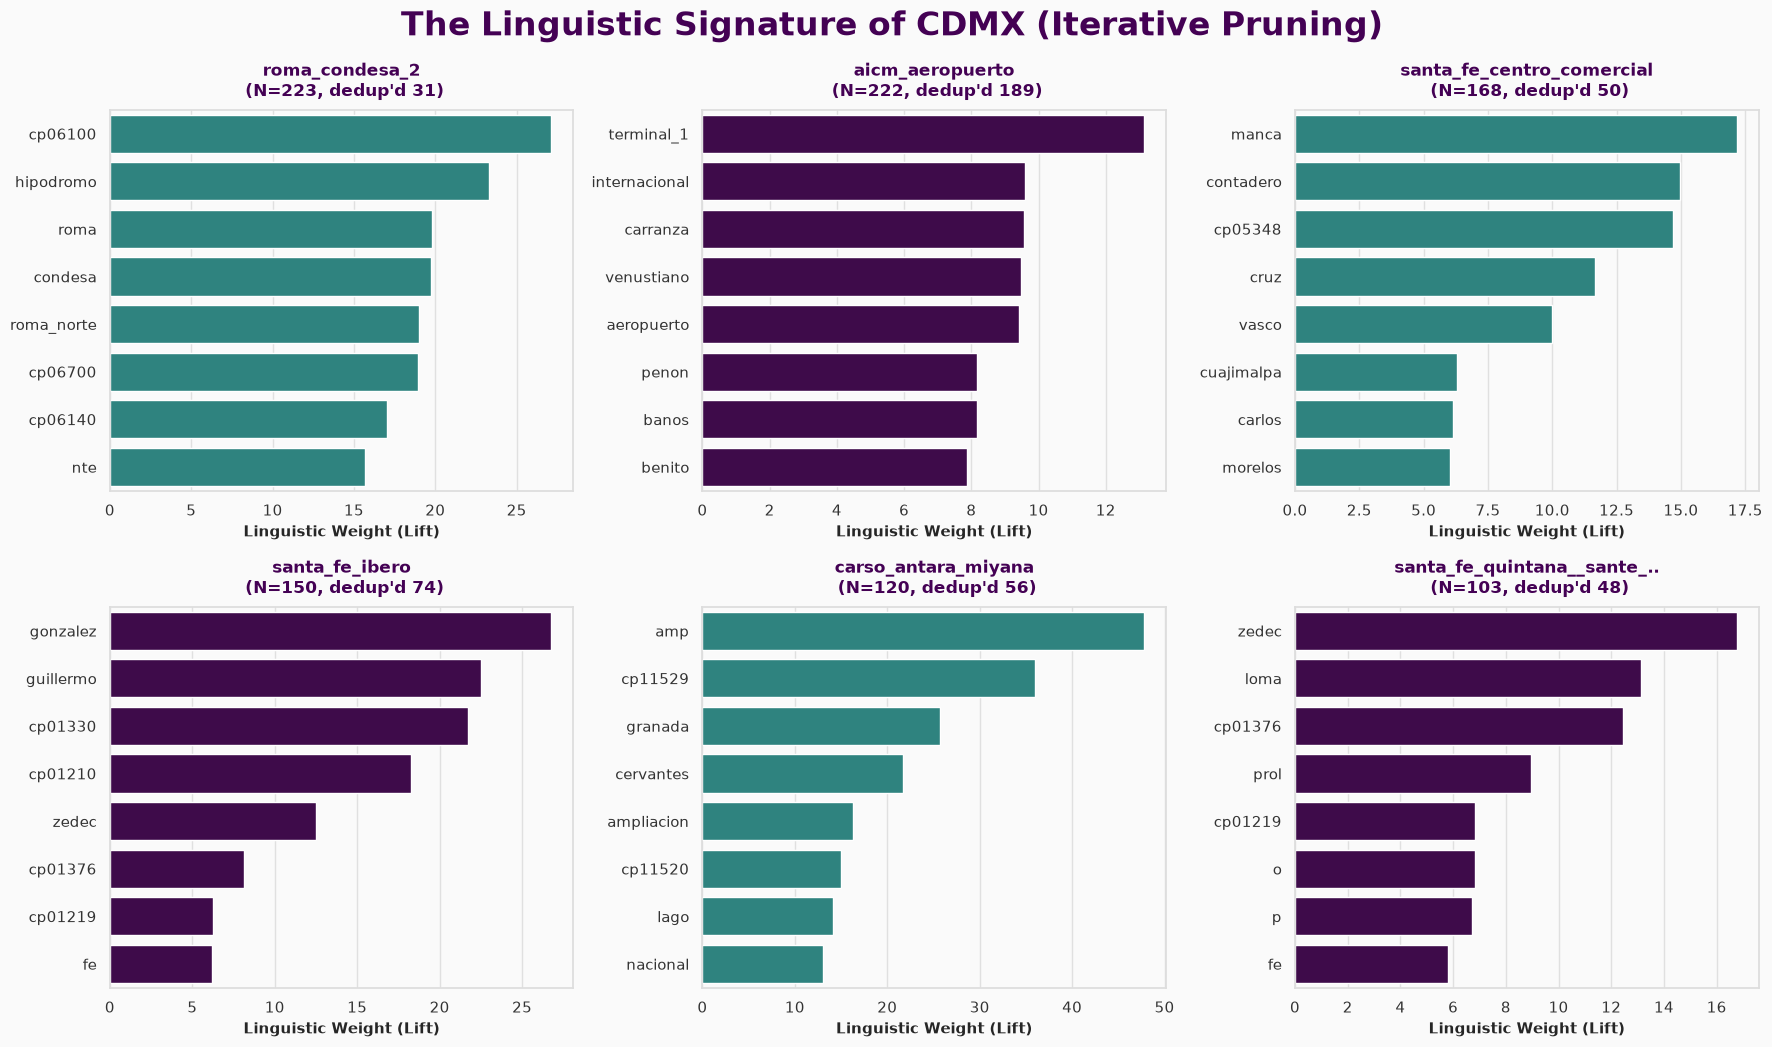

Urban lexicon visualizer executed successfully.


In [28]:
print("Analyzing the DNA of urban vocabulary (iterative pruning mode)...")

# --- 1. Configuration & pruning thresholds ---
TARGET_TOP_N_ZONES = 6
MIN_GLOBAL_WORD_COUNT = 3  # Word must appear at least 3 times globally

# --- 2. Global preparation (noise filtering) ---
global_tokens = [t for addr in df_model['clean_address'] for t in str(addr).split()]
global_token_counts = Counter(global_tokens)
total_words_global = sum(global_token_counts.values())

# Identify globally-rare "noise vocabulary"
rare_global_words = {word for word, count in global_token_counts.items() if count < MIN_GLOBAL_WORD_COUNT}
print(f"Noise pruning: ignoring {len(rare_global_words)} rare global words.")

# --- 3. Audit & visualization ---
zone_lexicons = []

target_zones_counts = df_model['final_zone_name'].value_counts()
target_zones = target_zones_counts.nlargest(TARGET_TOP_N_ZONES).index.tolist()

plt.figure(figsize=(18, 11), facecolor=PIENZA_GREY)

for i, zone in enumerate(target_zones):
    plt.subplot(2, 3, i + 1)

    # A. Intra-zone address deduplication
    zone_addrs_df = df_model[df_model['final_zone_name'] == zone]

    initial_zone_len = len(zone_addrs_df)
    unique_zone_addrs_df = zone_addrs_df.drop_duplicates(subset=['clean_address']).copy()
    num_addrs_deduplicated = initial_zone_len - len(unique_zone_addrs_df)

    zone_tokens = [t for addr in unique_zone_addrs_df['clean_address'] for t in str(addr).split()]

    # B. Apply noise pruning (remove globally rare words)
    zone_tokens_clean = [t for t in zone_tokens if t not in rare_global_words]

    zone_counts = Counter(zone_tokens_clean)
    num_zone_words = len(zone_tokens_clean)

    # If the zone is very small, force more distinction by picking fewer words
    top_N_most_common = 5 if num_zone_words < 100 else 8

    lift_data_for_zone = []

    # C. Calculate specificity only for the clean, deduplicated intra-zone vocabulary
    for word, count in zone_counts.most_common(20):
        if count < 2:
            continue  # Ignore tokens that only appear once inside a clean zone

        prob_zone = count / num_zone_words
        prob_global = global_token_counts[word] / total_words_global
        lift = prob_zone / prob_global

        lift_data_for_zone.append({
            'Zone': zone,
            'Word': word,
            'Count': count,
            'Specificity (Lift)': lift
        })

    # D. Plot
    df_lexicon_zone = pd.DataFrame(lift_data_for_zone)

    if df_lexicon_zone.empty:
        plt.title(f"{zone}\n(Filtered out due to low variance)", fontsize=12, color=PIENZA_PURPLE)
        continue

    top_words = df_lexicon_zone.nlargest(top_N_most_common, 'Specificity (Lift)').sort_values(by='Specificity (Lift)', ascending=False)

    bar_color = PIENZA_TEAL if i % 2 == 0 else PIENZA_PURPLE

    sns.barplot(
        data=top_words,
        x='Specificity (Lift)',
        y='Word',
        hue='Word',
        palette=[bar_color] * len(top_words),
        legend=False
    )

    short_name = (zone[:25] + '..') if len(zone) > 25 else zone
    subtitle = short_name
    subtitle_volume = f" (N={target_zones_counts[zone]}, dedup'd {num_addrs_deduplicated})"

    plt.title(f"{subtitle}\n{subtitle_volume}", fontsize=12, fontweight='bold', color=PIENZA_PURPLE, pad=10)
    plt.xlabel("Linguistic Weight (Lift)", fontsize=11, fontweight='bold')
    plt.ylabel("")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("The Linguistic Signature of CDMX (Iterative Pruning)", fontsize=24, fontweight='bold', color=PIENZA_PURPLE)
plt.show()

print("Urban lexicon visualizer executed successfully.")


#### 5.3 — The Transformer architecture

A small Transformer encoder with sinusoidal positional encoding and a max+average pooling fusion head (captures both the overall address context and the single sharpest signal, e.g. a specific street name).

In [29]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class ZoneClassifierTransformer(nn.Module):
    def __init__(self, vocab_size, num_classes, d_model=128, nhead=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.dropout = nn.Dropout(dropout)

        # The classifier expects 2x d_model due to the max + avg fusion
        self.classifier = nn.Linear(d_model * 2, num_classes)
        self.d_model = d_model

    def forward(self, x):
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)

        # 1. Max-average pooling fusion
        avg_pool = x.mean(dim=1)   # Overall sentence context
        max_pool, _ = x.max(dim=1)  # Sharpest signal (e.g. a specific street name)

        fused_features = torch.cat((avg_pool, max_pool), dim=1)

        # 2. Bottleneck dropout
        fused_features = self.dropout(fused_features)

        # 3. Final classification
        logits = self.classifier(fused_features)
        return logits


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Architecture deployed. Using device: {device}")


Architecture deployed. Using device: cpu


#### 5.4 — Champion loading / training

Loads the cached champion weights if present (skipping training), otherwise trains from scratch with early stopping on validation F1, then prints the final classification report.

In [30]:
print("Initializing miniBabel architecture (Transformer V2)...")

# --- 1. Architecture setup ---
best_params = {'d_model': 256, 'nhead': 8, 'num_layers': 2, 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 1e-4}

model = ZoneClassifierTransformer(
    vocab_size=len(token_to_idx),
    num_classes=len(unique_zones),
    d_model=best_params['d_model'],
    nhead=best_params['nhead'],
    num_layers=best_params['num_layers'],
    dropout=best_params['dropout']
).to(device)

MODEL_PATH = os.path.join(DUMP_DIR, f"{DATE_PREFIX}_pienza_babel_champion.pth")

# --- 2. Load vs train ---
should_train = not os.path.exists(MODEL_PATH) or FORCE_UPDATE

if not should_train:
    print(f"Loading champion weights from {MODEL_PATH}...")
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print("Model loaded successfully. Skipping training.")
else:
    print("Starting training from scratch (canonical 256/8 architecture)...")

    optimizer = torch.optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    EPOCHS = 30
    patience = 5
    best_val_f1 = 0
    best_model_wts = copy.deepcopy(model.state_dict())
    no_improve_epochs = 0

    print(f"Training on {device}...")
    print("-" * 80)

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item()
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().tolist())
                all_labels.extend(labels.cpu().tolist())

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        current_val_acc = accuracy_score(all_labels, all_preds)
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)

        print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_train_loss:.3f}/{avg_val_loss:.3f} | Acc: {current_val_acc:.2%} | F1: {f1:.3f}")

        if f1 > best_val_f1:
            best_val_f1 = f1
            best_model_wts = copy.deepcopy(model.state_dict())
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}.")
                break

    model.load_state_dict(best_model_wts)
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Training complete. Weights saved to {MODEL_PATH}")

# --- 3. Final scientific evaluation report ---
print("\n" + "=" * 80)
print("FINAL SCIENTIFIC EVALUATION REPORT (CUSTOM TRANSFORMER)")
print("=" * 80)

model.eval()
final_preds, final_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        final_preds.extend(preds.cpu().tolist())
        final_labels.extend(labels.cpu().tolist())

target_names = [idx_to_zone[i] for i in range(len(unique_zones))]
print(classification_report(final_labels, final_preds, target_names=target_names, zero_division=0))
print("-" * 80)


Initializing miniBabel architecture (Transformer V2)...
Loading champion weights from /workspaces/pienza/data/dumped_files/260422_pienza_babel_champion.pth...
Model loaded successfully. Skipping training.

FINAL SCIENTIFIC EVALUATION REPORT (CUSTOM TRANSFORMER)
              precision    recall  f1-score   support

         C_0       1.00      1.00      1.00         8
         C_1       0.88      0.95      0.91        22
        C_10       0.83      0.71      0.77         7
        C_11       0.86      0.75      0.80         8
        C_12       0.60      0.50      0.55         6
        C_13       1.00      0.50      0.67         2
        C_15       0.50      1.00      0.67         1
        C_16       1.00      1.00      1.00         1
        C_17       0.67      1.00      0.80         6
        C_19       1.00      1.00      1.00         2
         C_2       0.93      0.87      0.90        15
        C_22       0.62      0.80      0.70        10
        C_23       1.00      1.00  

## Phase 6 — Model audit

A randomized cross-section of the validation set, showing both correct and incorrect predictions side by side for a qualitative sense of where the model succeeds and fails.

#### 6.1 — Randomized contrast audit (hits & misses)

In [31]:
# --- 1. Boot the inference engine ---
zone_map = df_nav[['final_zone_id', 'final_zone_name']].drop_duplicates().set_index('final_zone_id')['final_zone_name'].to_dict()

def predict_zone(address_text):
    model.eval()
    clean_text = standardize_mexico_city_address(address_text)
    tokens = clean_text.split()
    indices = [token_to_idx.get(t, token_to_idx['<unk>']) for t in tokens]

    if len(indices) < MAX_LEN:
        indices += [token_to_idx['<pad>']] * (MAX_LEN - len(indices))
    else:
        indices = indices[:MAX_LEN]

    tensor_in = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor_in)
        probs = torch.softmax(logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item()

    zone_id = idx_to_zone[pred_idx]
    zone_name = zone_map.get(zone_id, "Unknown Name")
    return zone_name, confidence, clean_text

# --- 2. Randomized sampling ---
model.eval()
hits, misses = [], []

val_data = list(zip(X_val, y_val))
random.shuffle(val_data)  # Fresh sample every run

print("Randomly scanning the validation set for contrast samples...")

for addr, real_id in val_data:
    if len(hits) >= 5 and len(misses) >= 5:
        break

    pred_name, confidence, _ = predict_zone(addr)
    real_name = zone_map.get(real_id, "Unknown")
    is_correct = (pred_name == real_name)

    entry = {
        'Address_Fed_To_Model': _obf_address(addr),  # display only -- prediction above used the real addr
        'Real_Zone': real_name,
        'Predicted_Zone': pred_name,
        'Confidence': f"{confidence:.1%}",
        'Result': "HIT" if is_correct else "MISS",
    }

    if is_correct and len(hits) < 5:
        hits.append(entry)
    elif not is_correct and len(misses) < 5:
        misses.append(entry)

df_raw_audit = pd.concat([pd.DataFrame(hits), pd.DataFrame(misses)])

print("\n" + "=" * 100)
print("Randomized validation audit")
print("=" * 100)
pd.set_option('display.max_colwidth', None)
display(df_raw_audit)


Randomly scanning the validation set for contrast samples...



Randomized validation audit


,Address_Fed_To_Model,Real_Zone,Predicted_Zone,Confidence,Result
0,av de las fuentes_13 cp53950 naucalpan de juarez mexico lomas de chapultepec,fuentes_casino__sedena__tecamachalco,fuentes_casino__sedena__tecamachalco,97.4%,HIT
1,carretera federal mexico toluca_5860 col el contadero cp05500 cuajimalpa de morelos cuajimalpa,carretera_al_olivo__carretera_libre__cruce_echanove__vistahermosa,carretera_al_olivo__carretera_libre__cruce_echanove__vistahermosa,96.4%,HIT
2,av periferico_sur_3720 alvaro obregon cp01900 alvaro obregon ciudad de mexico jardines del pedregal,pedregal,pedregal,97.7%,HIT
3,paseo interlomas vialidad de la barranca_6 cp52787 huixquilucan em interlomas,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,98.3%,HIT
4,av juan salvador agraz_61 cp05310 cuajimalpa de morelos ciudad de mexico santa fe,santa_fe_centro_comercial,santa_fe_centro_comercial,97.7%,HIT
0,altillo universidad cp04310 ciudad de mexico cdmx mexico coyoacan,san_angel_altavista,barranca_del_muerto,74.5%,MISS
1,av cuajimalpa_42 cp52779 miguel hidalgo mexico interlomas,herradura_conscripto,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,65.0%,MISS
2,av juan vazquez de mella_481 col los morales polanco cp11510 miguel hidalgo,irrigacion__polanco_uber_hq,polanco_grupo_mexico__polanco_palacio,82.4%,MISS
3,calle roberto gayol_48 del valle centro cp03100 benito juarez del valle,felix_cuevas,napoles_wtc,79.9%,MISS
4,a musset_335 polanco polanco v secc miguel hidalgo cp11560 ciudad de mexico cdmx mexico,polanco_parroquia,polanco_5,76.0%,MISS


## Phase 7 — Alternate architecture: BETO fine-tune

Fine-tunes `dccuchile/bert-base-spanish-wwm-cased` (BETO) with the same max+avg pooling head as the custom Transformer, as a comparison point. A cached checkpoint already exists, so this loads it rather than re-fine-tuning (25 epochs of BERT fine-tuning on CPU would otherwise take a long time in this environment).

#### 7.1 — BETO (Spanish BERT) fine-tune

In [32]:
# --- 1. Silencers & auth ---
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
hf_logging.set_verbosity_error()

hf_token = os.environ.get("HF_TOKEN")
if hf_token:
    print("Hugging Face token detected. Authenticating...")
    login(token=hf_token)
else:
    print("HF_TOKEN not found. Continuing in anonymous mode.")

print("\nAwakening BETO (Spanish BERT) via AutoAPI...")

# --- 2. Tokenizer & data preparation ---
model_name = "dccuchile/bert-base-spanish-wwm-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def bert_encode(addresses, max_len=64):
    input_ids, attention_masks = [], []
    for addr in addresses:
        encoded = tokenizer(
            str(addr), add_special_tokens=True, max_length=max_len,
            padding='max_length', return_attention_mask=True,
            truncation=True, return_tensors='pt'
        )
        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])
    return torch.cat(input_ids, dim=0), torch.cat(attention_masks, dim=0)

print("Tokenizing for BERT (X_train and X_val)...")
train_ids, train_masks = bert_encode(X_train)
val_ids, val_masks = bert_encode(X_val)

train_y = torch.tensor([zone_to_idx[y] for y in y_train])
val_y = torch.tensor([zone_to_idx[y] for y in y_val])

bert_train_loader = DataLoader(TensorDataset(train_ids, train_masks, train_y), batch_size=16, shuffle=True)
bert_val_loader = DataLoader(TensorDataset(val_ids, val_masks, val_y), batch_size=16)

# --- 3. BETO architecture ---
class BETOWithCustomHead(nn.Module):
    def __init__(self, model_name, num_classes, dropout_rate=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(768 * 2, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()

        sum_embeddings = torch.sum(hidden_states * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        avg_pool = sum_embeddings / sum_mask

        hidden_states_masked = hidden_states.masked_fill(input_mask_expanded == 0, -1e9)
        max_pool, _ = torch.max(hidden_states_masked, dim=1)

        fused_features = torch.cat((avg_pool, max_pool), dim=1)
        return self.classifier(self.dropout(fused_features))

# --- 4. Load vs train ---
model_bert = BETOWithCustomHead(model_name, num_classes=len(unique_zones)).to(device)
BETO_PATH = os.path.join(DUMP_DIR, f"{DATE_PREFIX}_pienza_babel_beto_champion.pth")

if os.path.exists(BETO_PATH) and not FORCE_UPDATE:
    print(f"Loading BETO weights from {BETO_PATH}...")
    model_bert.load_state_dict(torch.load(BETO_PATH, map_location=device))
    model_bert.eval()
    print("miniBETO loaded successfully on CPU.")
else:
    print(f"Fine-tuning BETO on {device}...")
    optimizer = AdamW(model_bert.parameters(), lr=2e-5, eps=1e-8)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    EPOCHS_BETO, patience, best_val_f1 = 25, 5, 0
    best_model_wts = copy.deepcopy(model_bert.state_dict())
    no_improve_epochs = 0

    for epoch in range(EPOCHS_BETO):
        model_bert.train()
        for batch in bert_train_loader:
            b_input_ids, b_input_mask, b_labels = [t.to(device) for t in batch]
            model_bert.zero_grad()
            logits = model_bert(b_input_ids, b_input_mask)
            loss = criterion(logits, b_labels)
            loss.backward()
            optimizer.step()

        model_bert.eval()
        all_preds = []
        with torch.no_grad():
            for batch in bert_val_loader:
                b_input_ids, b_input_mask, _ = [t.to(device) for t in batch]
                logits = model_bert(b_input_ids, b_input_mask)
                all_preds.extend(torch.argmax(logits, dim=1).cpu().tolist())

        precision, recall, f1, _ = precision_recall_fscore_support(val_y.tolist(), all_preds, average='weighted', zero_division=0)
        print(f"Epoch {epoch+1:02d} | F1-Score (val): {f1:.3f}")

        if f1 > best_val_f1:
            best_val_f1 = f1
            best_model_wts = copy.deepcopy(model_bert.state_dict())
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                break

    model_bert.load_state_dict(best_model_wts)
    torch.save(model_bert.state_dict(), BETO_PATH)
    print(f"Fine-tuning complete. Saved to {BETO_PATH}")

# --- 5. Final scientific evaluation ---
print("\n" + "=" * 80)
print("FINAL SCIENTIFIC EVALUATION REPORT (BETO)")
print("=" * 80)

model_bert.eval()
final_preds = []
with torch.no_grad():
    for batch in bert_val_loader:
        b_input_ids, b_input_mask, _ = [t.to(device) for t in batch]
        logits = model_bert(b_input_ids, b_input_mask)
        final_preds.extend(torch.argmax(logits, dim=1).cpu().tolist())

target_names = [idx_to_zone[i] for i in range(len(unique_zones))]
print(classification_report(val_y.tolist(), final_preds, target_names=target_names, zero_division=0))
print("-" * 80)


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Hugging Face token detected. Authenticating...

Awakening BETO (Spanish BERT) via AutoAPI...
Tokenizing for BERT (X_train and X_val)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading BETO weights from /workspaces/pienza/data/dumped_files/260422_pienza_babel_beto_champion.pth...
miniBETO loaded successfully on CPU.

FINAL SCIENTIFIC EVALUATION REPORT (BETO)
              precision    recall  f1-score   support

         C_0       0.89      1.00      0.94         8
         C_1       0.83      0.86      0.84        22
        C_10       0.57      0.57      0.57         7
        C_11       0.89      1.00      0.94         8
        C_12       0.80      0.67      0.73         6
        C_13       0.50      0.50      0.50         2
        C_15       1.00      1.00      1.00         1
        C_16       1.00      1.00      1.00         1
        C_17       0.86      1.00      0.92         6
        C_19       1.00      1.00      1.00         2
         C_2       1.00      0.87      0.93        15
        C_22       0.80      0.80      0.80        10
        C_23       1.00      1.00      1.00         6
        C_29       1.00      1.00      1.00         6
     

## Phase 8 — Export artifacts

Exports a holdout audit parquet (predictions vs. ground truth, for downstream review) and the production artifacts (vocabulary + semantic zone map) the Observatory needs to run inference on raw text.

#### 8.1 — Export holdout audit parquet

Re-runs inference on the validation set and saves a parquet with raw address, cleaned address, real vs. predicted zone, and confidence.

In [33]:
print("Rebuilding the holdout audit with semantic zone names...")

# Direct semantic map built from the in-memory DataFrame (no external JSON needed)
zone_to_semantic = df_nav[['final_zone_id', 'final_zone_name']].drop_duplicates().set_index('final_zone_id')['final_zone_name'].to_dict()

# zone_to_idx (from 5.1): zone_id -> integer (e.g. "P_1" -> 11)
clean_to_raw = df_nav.set_index("clean_address")["dropoff_address"].to_dict() if "dropoff_address" in df_nav.columns else {}

model.eval()
records = []

with torch.no_grad():
    for clean_addr, true_zone in zip(X_val, y_val):
        raw_addr = clean_to_raw.get(str(clean_addr), str(clean_addr))

        tokens = str(clean_addr).split()
        indices = [token_to_idx.get(t, token_to_idx.get("<unk>", 1)) for t in tokens]
        indices = indices[:30] + [token_to_idx.get("<pad>", 0)] * max(0, 30 - len(indices))

        tensor_in = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)

        logits = model(tensor_in)
        probs = F.softmax(logits, dim=1)
        conf, pred_idx = torch.max(probs, dim=1)

        pred_zone_id = idx_to_zone.get(pred_idx.item(), "unknown")
        pred_zone_name = zone_to_semantic.get(pred_zone_id, pred_zone_id)

        real_zone_id = str(true_zone)
        real_zone_name = zone_to_semantic.get(real_zone_id, real_zone_id)

        records.append({
            "raw_address": raw_addr,
            "clean_address": str(clean_addr),
            "real_zone": real_zone_id,
            "real_zone_name": real_zone_name,
            "predicted_zone": pred_zone_name,
            "confidence": round(conf.item(), 4),
            # Compare raw zone IDs (matches the sklearn accuracy_score in 5.4),
            # not semantic names -- multiple raw zone IDs can share the same
            # semantic name (merged/duplicate zones), which would inflate
            # accuracy if compared by name instead of by ID.
            "correct": pred_zone_id == real_zone_id,
        })

df_audit = pd.DataFrame(records)
print(f"Done. {len(df_audit)} records | Accuracy: {df_audit['correct'].mean():.2%}")

# Display preview only -- raw_address is obfuscated on-screen; the parquet
# export below keeps the real, unmasked values for downstream ML use.
df_audit_display = df_audit.head(3).copy()
df_audit_display['raw_address'] = df_audit_display['raw_address'].apply(_obf_address)
print(df_audit_display.to_string())

OUT_PATH = os.path.join(DUMP_DIR, "260702_minibabel_holdout_audit.parquet")
df_audit.to_parquet(OUT_PATH, index=False)
print("Saved ->", OUT_PATH)


Rebuilding the holdout audit with semantic zone names...
Done. 678 records | Accuracy: 84.22%
                                                                                                                 raw_address                                                                                           clean_address real_zone             real_zone_name                                predicted_zone  confidence  correct
0  Blvd. Miguel de Cervantes Saavedra ###, Granada, Miguel Hidalgo, 11520 Ciudad de México, CDMX, México - Polanco / Anzures       blvd miguel de cervantes saavedra_161 granada miguel hidalgo cp11520 ciudad de mexico cdmx mexico      P_35                      lagos                                         lagos      0.9913     True
1                Vasco de Quiroga ####, La Ponderosa, Cuajimalpa de Morelos, 05370 Ciudad de México, CDMX, México - Santa Fe  vasco de quiroga_4973 la ponderosa cuajimalpa de morelos cp05370 ciudad de mexico cdmx mexico santa fe       P_1  

#### 8.2 — Export production artifacts (vocab & semantic map)

Saves the index-to-semantic-name map and the tokenizer vocabulary, both needed by the Observatory to run inference on raw text input.

In [34]:
print("Materializing production artifacts...")

# 1. Build the direct semantic map (model's integer prediction -> human-readable name)
zone_to_semantic = df_nav[['final_zone_id', 'final_zone_name']].drop_duplicates().set_index('final_zone_id')['final_zone_name'].to_dict()

idx_to_semantic_name = {}
for idx, zone_id in idx_to_zone.items():
    semantic_name = zone_to_semantic.get(zone_id, zone_id)
    idx_to_semantic_name[str(idx)] = semantic_name

semantic_path = os.path.join(DUMP_DIR, "idx_to_zone_to_semantics.json")
with open(semantic_path, 'w', encoding='utf-8') as f:
    json.dump(idx_to_semantic_name, f, ensure_ascii=False, indent=4)
print(f"Semantic mapping saved ({len(idx_to_semantic_name)} classes) -> {semantic_path}")

# 2. Save the tokenizer vocabulary (crucial so downstream consumers convert
# raw text to the same integer indices)
vocab_path = os.path.join(DUMP_DIR, "token_to_idx.json")
with open(vocab_path, 'w', encoding='utf-8') as f:
    json.dump(token_to_idx, f, ensure_ascii=False, indent=4)
print(f"Tokenizer vocabulary saved ({len(token_to_idx)} tokens) -> {vocab_path}")

print("\nAll production artifacts are ready for export.")


Materializing production artifacts...
Semantic mapping saved (63 classes) -> /workspaces/pienza/data/dumped_files/idx_to_zone_to_semantics.json
Tokenizer vocabulary saved (2502 tokens) -> /workspaces/pienza/data/dumped_files/token_to_idx.json

All production artifacts are ready for export.


---

## Appendix — variable journey

```mermaid
flowchart TD
    ocr["pienza.db: OCR + silver join"] --> df_input["df_input\n(raw addresses + zone labels)"]
    df_input --> df_nav["df_nav\n(master coalesce, final_zone_id/name)"]

    df_nav --> standardized["Standardized addresses\n(Hard-Cut, noise-filtered)"]
    standardized --> tfidf["tfidf_final\n(TF-IDF street signals)"]
    tfidf --> w2v["w2v_model\n(Word2Vec embeddings)"]

    df_nav --> loaders["Neural DataLoaders\n(stratified split, safety purge)"]
    w2v --> model["model\n(Transformer V2, positional encoding)"]
    loaders --> model
    model --> audit["Randomized contrast audit\n(hits vs. misses)"]

    df_nav --> beto["BETO (Spanish BERT)\nfine-tune, alternate architecture"]

    audit --> exports["Holdout audit parquet +\nvocab/semantic-map production artifacts"]
    beto --> exports

    classDef default stroke:#21918c,stroke-width:2px;
    linkStyle default stroke:#21918c,stroke-width:2px;
```